# Ecommerce Linear Regression Project

This notebook covers an end-to-end **Linear Regression** use case using ecommerce data.

## Objective
Predict **sales_amount** based on:
- categorical features
- numerical features
- basic preprocessing
- model training
- evaluation
- prediction on new input

---


## Task 1: Import libraries

Load all required Python libraries for:
- data handling
- preprocessing
- model building
- evaluation


In [31]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt


## Task 2: Read the ecommerce CSV file

In [32]:
df=pd.read_csv('ecommerce_regression_data.csv')
df.head()

,product_category,customer_segment,payment_method,units_sold,discount_pct,ad_spend,customer_rating,returns_count,is_festival_season,sales_amount
0,Beauty,Regular,UPI,1,33,1832.03,4.1,0,1,1307.65
1,Electronics,Prime,Wallet,8,30,3331.92,3.9,2,1,2605.51
2,Home,Business,UPI,7,22,2531.15,4.5,2,0,2530.16
3,Electronics,Regular,UPI,5,36,2245.48,4.0,2,0,1719.26
4,Fashion,Regular,Card,5,5,2404.44,3.9,3,0,2131.67


## Task 3: Check shape and column names

In [33]:
df.shape
df.columns

Index(['product_category', 'customer_segment', 'payment_method', 'units_sold',
       'discount_pct', 'ad_spend', 'customer_rating', 'returns_count',
       'is_festival_season', 'sales_amount'],
      dtype='str')

## Task 4: Explore dataset information and missing values

In [34]:
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_category    990 non-null    str    
 1   customer_segment    990 non-null    str    
 2   payment_method      990 non-null    str    
 3   units_sold          1000 non-null   int64  
 4   discount_pct        1000 non-null   int64  
 5   ad_spend            985 non-null    float64
 6   customer_rating     985 non-null    float64
 7   returns_count       1000 non-null   int64  
 8   is_festival_season  1000 non-null   int64  
 9   sales_amount        1000 non-null   float64
dtypes: float64(3), int64(4), str(3)
memory usage: 97.9 KB


product_category      10
customer_segment      10
payment_method        10
units_sold             0
discount_pct           0
ad_spend              15
customer_rating       15
returns_count          0
is_festival_season     0
sales_amount           0
dtype: int64

## Task 5: Summary statistics

In [35]:
df.describe()


,units_sold,discount_pct,ad_spend,customer_rating,returns_count,is_festival_season,sales_amount
count,1000.000000,1000.000000,985.000000,985.000000,1000.000000,1000.000000,1000.000000
mean,5.531000,19.874000,2430.335766,4.105076,1.438000,0.225000,2146.947540
std,2.878076,11.948678,911.384942,0.488771,1.124019,0.417791,552.016871
min,1.000000,0.000000,200.000000,2.600000,0.000000,0.000000,423.460000
25%,3.000000,10.000000,1832.030000,3.800000,0.000000,0.000000,1764.660000
50%,6.000000,20.000000,2464.260000,4.100000,1.000000,0.000000,2141.540000
75%,8.000000,30.000000,3052.840000,4.500000,2.000000,0.000000,2550.967500
max,10.000000,40.000000,5122.820000,5.000000,3.000000,1.000000,3776.170000


In [36]:
df.describe(include='object')

C:\Users\Chadagonda.Reddy\AppData\Local\Temp\ipykernel_26444\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,product_category,customer_segment,payment_method
count,990,990,990
unique,5,3,4
top,Electronics,Regular,NetBanking
freq,287,625,282


## Task 6: Define target and input features

Target column:
- `sales_amount`

Input columns:
- all remaining columns


In [37]:
target_col = 'sales_amount'
X = df.drop(columns=[target_col])
y = df[target_col]

## Task 7: Build preprocessing pipelines

### For categorical columns
- fill missing values with most frequent value
- apply one-hot encoding

### For numerical columns
- fill missing values with median


In [38]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print('Categorical columns:', categorical_cols)
print('Numerical columns:', numerical_cols)
numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
numeric_transformer = Pipeline(steps=numeric_steps)
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numerical_cols),('cat', categorical_transformer, categorical_cols)])



Categorical columns: ['product_category', 'customer_segment', 'payment_method']
Numerical columns: ['units_sold', 'discount_pct', 'ad_spend', 'customer_rating', 'returns_count', 'is_festival_season']


C:\Users\Chadagonda.Reddy\AppData\Local\Temp\ipykernel_26444\979307374.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


## Task 8: Split data into train and test sets

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Task 9: Create Linear Regression model pipeline

In [40]:

model = LinearRegression()
pipeline = Pipeline(steps=[('preprocessor', preprocessor),('model', model)])
pipeline.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Task 10: Make predictions on test data

In [41]:
preds = pipeline.predict(X_test)

## Task 11: Evaluate the model

In [42]:
mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)

print('MAE :', round(mae, 4))
print('MSE :', round(mse, 4))
print('RMSE:', round(rmse, 4))
print('R2  :', round(r2, 4))

MAE : 98.4212
MSE : 17157.8066
RMSE: 130.9878
R2  : 0.9446


## Task 12: Visualize Actual vs Predicted

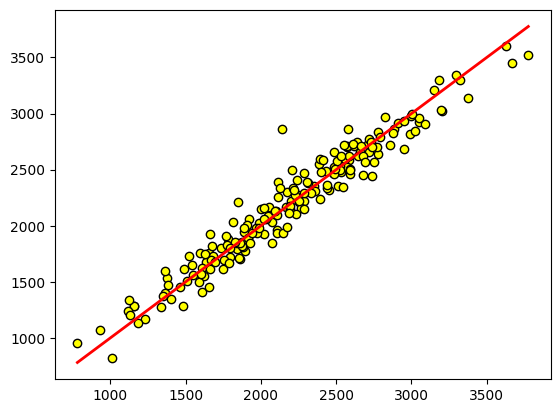

In [43]:

# Plot the results
plt.scatter(y_test, preds, color='yellow', edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.show()


## Task 13: Residual analysis

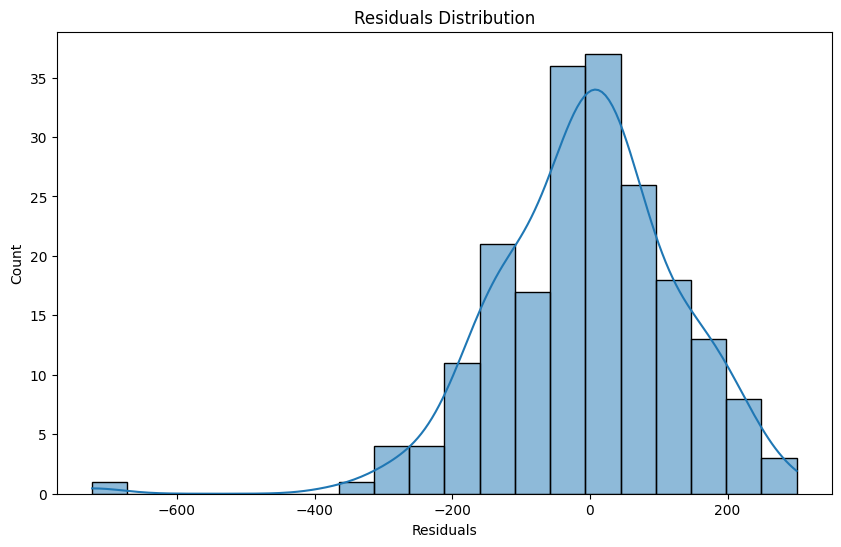

In [44]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(y_test -preds, kde=True)
plt.xlabel('Residuals')
plt.title('Residuals Distribution')
plt.show()




## Task 14: Predict sales for a new ecommerce record

In [45]:
new_record = pd.DataFrame([
    {
        'product_category': 'Electronics',
        'customer_segment': 'Prime',
        'payment_method': 'Card',
        'units_sold': 3,
        'discount_pct': 10,
        'ad_spend': 1500.00,
        'customer_rating': 4.5,
        'returns_count': 0,
        'is_festival_season': 0
    }
])
predicted_sales = pipeline.predict(new_record)
print(f'Predicted Sales Amount for the new record: {predicted_sales[0]:.2f}')

Predicted Sales Amount for the new record: 1848.50
